In [3]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd
from src.clean import load_clean

df = load_clean()
df.shape

(9994, 21)

1. 长相

In [13]:
print(df.head())
print(df.sample(5))
print(df.columns.tolist())

   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   South  FUR-BO-10

2. 质量

In [16]:
print(df.info())
print(df.isnull().sum())
print(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

3. 分布

In [6]:
df.describe()


,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


4. 数分类

主类
office 6026   furniture 2121   technology 1847

子类
binders:1523   paper:1370   furnishings:957   phones:889   storage:846   Art:796   Accessories:775
Chairs:617   Appliances:466   Labels:364   Tables:319   Envelopes:254   Bookcases:228   Fasteners:217
Supplies:190   Machines:115   Copiers:68

地区
West       3203
East       2848
Central    2323
South      1620

客户
Consumer       5191
Corporate      3020
Home Office    1783

运输模式
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543

In [7]:
df["Category"].value_counts()
df["Sub-Category"].value_counts()
df["Region"].value_counts()
df["Segment"].value_counts()
df["Ship Mode"].value_counts()

Ship Mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64

5. 看时间

max 9/9/2017
min 1/1/2017
导致这个结果的原因是Order Date这一列不是日期类型，是字符串类型。

再清洗完数据后，已将字符串类型改为了日期类型。

In [8]:
df["Order Date"].head()

df["Order Date"].dtype
df["Order Date"].min(),df["Order Date"].max()

(Timestamp('2014-01-03 00:00:00'), Timestamp('2017-12-30 00:00:00'))

看折扣和利润的关系

打八折和不打折为主要销售档位，两者合计销量占总销量的84.3%。

打七折及以下，亏损占总利润的47.3%，主要集中在 Binders、Tables、Machines 这几个子类别，如果是主动促销造成的，以后可减少这种促销。
若要判断是主动促销，还是被迫竞争，还需要结合内部的促销申请记录、竞品价格数据才能判断，单靠这份数据回答不了这个问题。

In [9]:
df["Discount"].value_counts().sort_index()

g = df.groupby("Discount")[["Sales", "Profit"]].sum()
g

g["数量"] = df["Discount"].value_counts().sort_index()
g["利润率"] = g["Profit"]/g["Sales"]
g

# 查看七折以下的负利润占总利润的多少
deep = df[df["Discount"]>=0.30]
deep.shape
deep["Discount"].value_counts().sort_index()
loss = deep["Profit"].sum()
loss
total = df["Profit"].sum()
print(f"7折及以下净贡献:{loss:,.0f}")
print(f"全表总利润:{total:,.0f}")
print(f"占总利润比例:{-loss/total:.1%}")

7折及以下净贡献:-135,376
全表总利润:286,397
占总利润比例:47.3%


In [10]:

g = df.groupby("Discount").agg(
    行数=("Sales", "size"),
    销售额=("Sales", "sum"),
    销售数量=("Quantity", "sum"),
)
g["平均每行金额"] = g["销售额"] / g["行数"]
g

,行数,销售额,销售数量,平均每行金额
Discount,,,,
0.00,4798,1.087908e+06,18267,226.742074
0.10,94,5.436935e+04,373,578.397351
0.15,52,2.755852e+04,198,529.971567
0.20,3657,7.645944e+05,13660,209.076940
0.30,227,1.032267e+05,849,454.742974
0.32,27,1.449346e+04,105,536.794770
0.40,206,1.164178e+05,786,565.134874
0.45,11,5.484974e+03,45,498.634000
0.50,66,5.891854e+04,241,892.705152


可视化

In [18]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# 让图标能显示中文。不加这两行，中文会变成一排小方框
matplotlib.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
matplotlib.rcParams["axes.unicode_minus"] = False  # 负号别变成方框

FIG_DIR = ROOT / "outputs" / "figures"

图一————折扣档位 vs 利润率

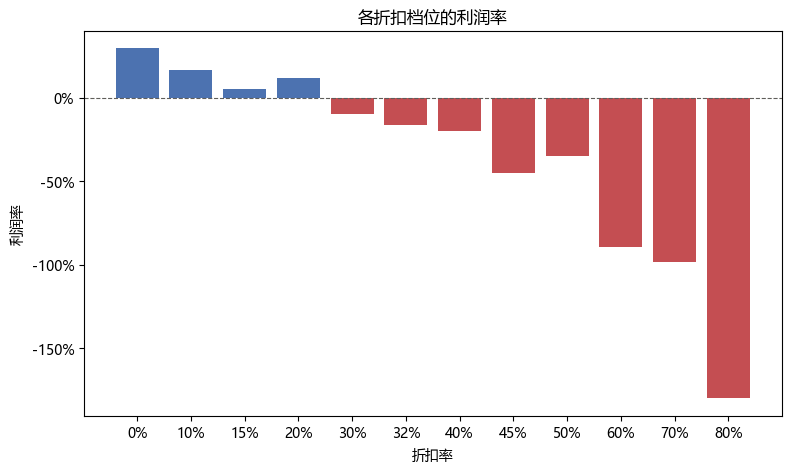

In [20]:
g = df.groupby("Discount").agg(销售额=("Sales", "sum"), 利润=("Profit", "sum"))
g["利润率"] = g["利润"] / g["销售额"]

xlabels = [f"{d:.0%}" for d in g.index]  # 0%、10%、15%
colors = ["#C44E52" if v < 0 else "#4C72B0" for v in g["利润率"]]  # 亏的标红

fig, ax = plt.subplots(figsize = (9, 5))
ax.bar(xlabels, g["利润率"], color = colors)
ax.axhline(0, color = "#5F5E5A", linewidth=0.8, linestyle="--") # 零钱：盈亏分界
ax.set_title("各折扣档位的利润率")
ax.set_xlabel("折扣率")
ax.set_ylabel("利润率")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
fig.savefig(FIG_DIR / "01_折扣档位利润率.png", bbox_inches="tight", dpi=120)
plt.show()

图二：两组对比

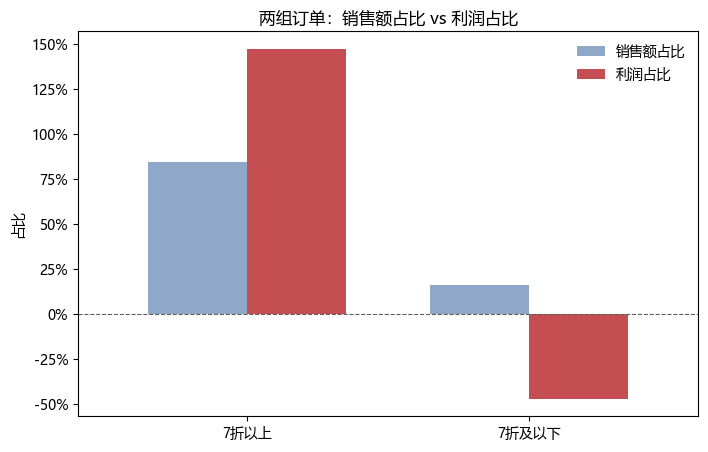

In [21]:
deep = df["Discount"] >= 0.30  # 7 折及以下
shallow = df["Discount"] < 0.30 # 7 折及以上
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()

share = pd.DataFrame({
    "销售额占比": [
        df.loc[shallow, "Sales"].sum() / total_sales,
        df.loc[deep, "Sales"].sum() / total_sales,
    ],
    "利润占比": [
        df.loc[shallow, "Profit"].sum() / total_profit,
        df.loc[deep, "Profit"].sum() / total_profit,
    ],
},index = ["7折以上", "7折及以下"])

fig, ax = plt.subplots(figsize=(8, 5))
share.plot(kind="bar", ax=ax, color=["#8FA8C8", "#C44E52"], rot=0, width=0.7)
ax.axhline(0, color="#5F5E5A", linewidth=0.8, linestyle="--")
ax.set_title("两组订单：销售额占比 vs 利润占比")
ax.set_ylabel("占比")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(frameon=False)
fig.savefig(FIG_DIR / "02_占比对比.png", bbox_inches="tight", dpi=120)
plt.show()

图三————子类别亏损排行

In [ ]:
loss = df[deep].groupby("Sub-Category")["Profit"].sum()
loss = loss[loss < 0].sort_values(ascending=False)
# 说明：barh 把第一行画在最下面，所以倒序排，才能让最亏的排在最上面

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(loss.index, loss.values, color="#C44E52")
ax.axvline(0, color="#5F5E5A", linewidth=0.8)
ax.set_title("深折扣订单（7折及以下）各子类别的亏损金额")
ax.set_xlabel("利润")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
fig.savefig(FIG_DIR / "03_子类别亏损.png", bbox_inches="tight", dpi=120)
plt.show()
